<a href="https://colab.research.google.com/github/DrishtiNigam1928/CUSTOMER_CHURN/blob/main/notebooks/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
from google.colab import files
uploaded = files.upload()


Saving train_dataset.csv to train_dataset (2).csv


In [94]:
import os
print(os.listdir())

['.config', 'train_dataset (1).csv', 'train_dataset.csv', 'E_Commerce_Training', 'train_dataset (2).csv', 'sample_data']


In [95]:
import pandas as pd
import numpy as np

# FILENAME = "E Commerce Dataset.xlsx"   # match this exactly to what os.listdir() showed
# df = pd.read_excel(FILENAME, sheet_name="E Comm")

# FILENAME = "test_dataset.csv"
FILENAME = "train_dataset.csv"
df = pd.read_csv(FILENAME)

print("Shape:", df.shape)
df.head()

Shape: (4504, 36)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,51783,0,3.0,Phone,3,13.0,E Wallet,Male,2.931535,3,...,1,0,0,0,0,1,0,0,0,1
1,53527,1,1.0,Phone,3,30.0,Debit Card,Female,3.000000,5,...,0,0,1,0,0,0,0,1,0,0
2,51188,1,0.0,Phone,2,24.0,Upi,Male,2.931535,1,...,0,1,0,0,0,1,0,0,1,0
3,50275,0,9.0,Phone,1,6.0,Debit Card,Male,3.000000,4,...,0,0,0,0,0,1,0,1,0,0
4,53337,0,27.0,Phone,3,15.0,E Wallet,Male,4.000000,4,...,1,0,0,1,0,0,0,1,0,0


In [96]:

num_rows = 0
for _ in df.itertuples():
    num_rows += 1
print("Number of rows/observations:", num_rows)

# 2. Number of columns/features (without .shape)
column_list = []
for col in df:
    column_list.append(col)
num_cols = len(column_list)
print("Number of columns/features:", num_cols)
print("Column names:", column_list)

Number of rows/observations: 4504
Number of columns/features: 36
Column names: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Gender_Encoded', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_Cash_On_Delivery', 'PreferredPaymentMode_Credit_Card', 'PreferredPaymentMode_Debit_Card', 'PreferredPaymentMode_E_Wallet', 'PreferredPaymentMode_Upi', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop_&_Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [97]:
#A2: Input features & Target variable
target_col = "Churn"
id_col = "CustomerID"

input_features = [c for c in df.columns if c not in [target_col, id_col]]

print("Target variable:", target_col)
print("Number of input features:", len(input_features))
print("Input features:", input_features)

Target variable: Churn
Number of input features: 34
Input features: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Gender_Encoded', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_Cash_On_Delivery', 'PreferredPaymentMode_Credit_Card', 'PreferredPaymentMode_Debit_Card', 'PreferredPaymentMode_E_Wallet', 'PreferredPaymentMode_Upi', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop_&_Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [98]:
#  A2: Numerical vs Categorical variables -
numerical_vars = df[input_features].select_dtypes(include=np.number).columns.tolist()
categorical_vars = df[input_features].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical variables (", len(numerical_vars), "):", numerical_vars)
print()
print("Categorical variables (", len(categorical_vars), "):", categorical_vars)


Numerical variables ( 29 ): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Gender_Encoded', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_Cash_On_Delivery', 'PreferredPaymentMode_Credit_Card', 'PreferredPaymentMode_Debit_Card', 'PreferredPaymentMode_E_Wallet', 'PreferredPaymentMode_Upi', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop_&_Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']

Categorical variables ( 5 ): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [99]:
# A2: Source of dataset -
print("Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction")
print("URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

Source: Kaggle - Ecommerce Customer Churn Analysis and Prediction
URL: https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction


In [100]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
count,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,...,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000,4504.000000
mean,52812.063277,0.167185,10.187833,1.660524,15.600355,2.924388,3.678508,3.071492,4.199156,0.279973,...,0.109680,0.075266,0.146314,0.072158,0.363233,0.371226,0.047069,0.146536,0.537300,0.316163
std,1622.033266,0.373182,8.373752,0.917656,8.382069,0.706585,1.015807,1.386379,2.575977,0.449036,...,0.312526,0.263850,0.353460,0.258778,0.480984,0.483186,0.211811,0.353682,0.498662,0.465029
min,50002.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51416.500000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,52788.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,54224.250000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,55629.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,21.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [101]:
def execute_task_B1(dataframe):
  print("Task B1: Initial Data Exploration and Structure Inspection\n")

  display(df.head(3))
  print("\n")
  display(df.tail(3))
  print("\n")
  rows, cols = dataframe.shape
  print(f"Total Number of Rows: {rows}\n")
  print(f"Total Number of Columns: {cols}\n")

  print(f"{'Column Name':<35} | {'Data Type':<15} | {'Unique Values':<15} | {'Missing Values'}")
  for col in dataframe.columns:
    col_name=col
    dtype=str(dataframe[col].dtype)
    unique_vals = dataframe[col].nunique()
    missing_vals = dataframe[col].isnull().sum()
    print(f"{col_name:<35} | {dtype:<15} | {unique_vals:<15} | {missing_vals}")

execute_task_B1(df)
print("\nTask B1 Completed Successfully!")


Task B1: Initial Data Exploration and Structure Inspection



,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,51783,0,3.0,Phone,3,13.0,E Wallet,Male,2.931535,3,...,1,0,0,0,0,1,0,0,0,1
1,53527,1,1.0,Phone,3,30.0,Debit Card,Female,3.000000,5,...,0,0,1,0,0,0,0,1,0,0
2,51188,1,0.0,Phone,2,24.0,Upi,Male,2.931535,1,...,0,1,0,0,0,1,0,0,1,0


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
4501,50205,0,20.0,Phone,1,11.0,Debit Card,Male,2.0,3,...,0,0,0,0,0,0,1,1,0,0
4502,50913,0,18.0,Phone,1,35.0,Cash On Delivery,Male,2.0,3,...,0,0,1,0,0,0,0,1,0,0
4503,55239,0,18.0,Phone,1,35.0,Debit Card,Male,3.0,4,...,0,0,0,1,0,0,0,0,1,0




Total Number of Rows: 4504

Total Number of Columns: 36

Column Name                         | Data Type       | Unique Values   | Missing Values
CustomerID                          | int64           | 4504            | 0
Churn                               | int64           | 2               | 0
Tenure                              | float64         | 35              | 0
PreferredLoginDevice                | object          | 2               | 0
CityTier                            | int64           | 3               | 0
WarehouseToHome                     | float64         | 34              | 0
PreferredPaymentMode                | object          | 5               | 0
Gender                              | object          | 2               | 0
HourSpendOnApp                      | float64         | 7               | 0
NumberOfDeviceRegistered            | int64           | 6               | 0
PreferedOrderCat                    | object          | 5               | 0
SatisfactionScor

In [102]:

# B2
def calc_mean(values):
    return sum(values) / len(values)

def calc_min(values):
    m = values[0]
    for v in values:
        if v < m:
            m = v
    return m

def calc_max(values):
    m = values[0]
    for v in values:
        if v > m:
            m = v
    return m

def calc_median(values):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2
    else:
        return sorted_vals[mid]

def calc_mode(values):
    freq = {}
    for v in values:
        freq[v] = freq.get(v, 0) + 1
    max_count = max(freq.values())
    for v, c in freq.items():
        if c == max_count:
            return v

def calc_variance(values, mean_val):
    squared_diffs = [(v - mean_val) ** 2 for v in values]
    return sum(squared_diffs) / len(values)   # population variance, matches the formula given

def calc_std(variance_val):
    return variance_val ** 0.5

def calc_range(min_val, max_val):
    return max_val - min_val

In [103]:

stats_dict = {}

for col in numerical_vars:
    values = [v for v in df[col] if pd.notna(v)]

    col_mean = calc_mean(values)
    col_min = calc_min(values)
    col_max = calc_max(values)
    col_median = calc_median(values)
    col_mode = calc_mode(values)
    col_variance = calc_variance(values, col_mean)
    col_std = calc_std(col_variance)
    col_range = calc_range(col_min, col_max)

    stats_dict[col] = {
        "Mean": col_mean, "Median": col_median, "Mode": col_mode,
        "Min": col_min, "Max": col_max, "Range": col_range,
        "Variance": col_variance, "Std Dev": col_std
    }

stats_table = pd.DataFrame(stats_dict).T
stats_table

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev
Tenure,10.187833,9.00,1.00,0.0,61.00,61.00,70.104150,8.372822
CityTier,1.660524,1.00,1.00,1.0,3.00,2.00,0.841905,0.917554
WarehouseToHome,15.600355,14.00,14.00,5.0,127.00,122.00,70.243481,8.381138
HourSpendOnApp,2.924388,3.00,3.00,0.0,5.00,5.00,0.499151,0.706506
NumberOfDeviceRegistered,3.678508,4.00,4.00,1.0,6.00,5.00,1.031634,1.015694
SatisfactionScore,3.071492,3.00,3.00,1.0,5.00,4.00,1.921621,1.386225
NumberOfAddress,4.199156,3.00,2.00,1.0,21.00,20.00,6.634182,2.575691
Complain,0.279973,0.00,0.00,0.0,1.00,1.00,0.201588,0.448986
OrderAmountHikeFromlastYear,15.670737,15.00,15.00,11.0,26.00,15.00,12.905129,3.592371
CouponUsed,1.708925,1.00,1.00,0.0,15.00,15.00,3.357771,1.832422


In [104]:
# C1
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Feature": missing_count.index,
    "Missing Values": missing_count.values,
    "Missing %": missing_pct.values
})
missing_table = missing_table[missing_table["Missing Values"] > 0].sort_values("Missing %", ascending=False)
missing_table

,Feature,Missing Values,Missing %


In [105]:
df_cleaned = df.copy()

# Mean used on HourSpendOnApp (Approximately symmetric)
df_cleaned["HourSpendOnApp"] = df_cleaned["HourSpendOnApp"].fillna(
    stats_dict["HourSpendOnApp"]["Mean"]
)

# Median used on Tenure, WarehouseToHome, OrderAmountHikeFromlastYear and DaySinceLastOrder (skewed data)
for col in ["Tenure", "WarehouseToHome",
            "OrderAmountHikeFromlastYear", "DaySinceLastOrder"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Median"]
    )

# Mode used on CouponUsed and OrderCount (Discrete/count variable)
for col in ["CouponUsed", "OrderCount"]:
    df_cleaned[col] = df_cleaned[col].fillna(
        stats_dict[col]["Mode"]
    )

# Before → After Missing Value Treatment
missing_features = ["Tenure","WarehouseToHome","HourSpendOnApp","OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder"]

before = df[missing_features].isnull().sum()
after = df_cleaned[missing_features].isnull().sum()

comparison = pd.DataFrame({
    "Feature": missing_features,
    "Before Missing Value Treatment": before.values,
    "After Missing Value Treatment": after.values
})

display(comparison)

,Feature,Before Missing Value Treatment,After Missing Value Treatment
0,Tenure,0,0
1,WarehouseToHome,0,0
2,HourSpendOnApp,0,0
3,OrderAmountHikeFromlastYear,0,0
4,CouponUsed,0,0
5,OrderCount,0,0
6,DaySinceLastOrder,0,0


In [106]:
# D1: Duplicate Detection
import pandas as pd

original_records = len(df_cleaned)

seen_ids = set()
duplicate_indices = []
duplicate_count = 0

for index, customer_id in enumerate(df_cleaned["CustomerID"]):
    if customer_id in seen_ids:
        duplicate_count += 1
        duplicate_indices.append(index)
    else:
        seen_ids.add(customer_id)

df_cleaned = df_cleaned.drop(duplicate_indices).reset_index(drop=True)
records_after_treatment = len(df_cleaned)

duplicate_summary_table = pd.DataFrame({
    "Item": ["Original Records", "Duplicate Records", "Records After Treatment"],
    "Value": [original_records, duplicate_count, records_after_treatment]
})

display(duplicate_summary_table)

,Item,Value
0,Original Records,4504
1,Duplicate Records,0
2,Records After Treatment,4504


In [107]:
#  D2: check ALL categorical columns ---
print("Full categorical variable list from A2:", categorical_vars)

for col in categorical_vars:
    print(f"--- {col} ---")
    print(df_cleaned[col].unique())
    print()

Full categorical variable list from A2: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
--- PreferredLoginDevice ---
['Phone' 'Computer']

--- PreferredPaymentMode ---
['E Wallet' 'Debit Card' 'Upi' 'Credit Card' 'Cash On Delivery']

--- Gender ---
['Male' 'Female']

--- PreferedOrderCat ---
['Mobile' 'Fashion' 'Grocery' 'Laptop & Accessory' 'Others']

--- MaritalStatus ---
['Single' 'Divorced' 'Married']



In [108]:
#  D2: Standardize categorical inconsistencies

standardization_map = {
    "PreferredLoginDevice": {
        "Mobile Phone": "Phone",
        "Phone": "Phone",
        "Computer": "Computer"
    },
    "PreferredPaymentMode": {
        "CC": "Credit Card",
        "Credit Card": "Credit Card",
        "COD": "Cash on Delivery",
        "Cash on Delivery": "Cash on Delivery",
        "Debit Card": "Debit Card",
        "E wallet": "E Wallet",
        "UPI": "UPI"
    },
    "PreferedOrderCat": {
        "Mobile Phone": "Mobile",
        "Mobile": "Mobile",
        "Laptop & Accessory": "Laptop & Accessory",
        "Fashion": "Fashion",
        "Grocery": "Grocery",
        "Others": "Others"
    }
}

for col, mapping in standardization_map.items():
    before_unique = df_cleaned[col].nunique()

    # Manual replacement logic
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip()          # remove extra spaces
            new_column.append(mapping.get(cleaned_value, cleaned_value))
    df_cleaned[col] = new_column

    after_unique = df_cleaned[col].nunique()
    print(f"{col}: {before_unique} unique values -> {after_unique} unique values after standardization")

PreferredLoginDevice: 2 unique values -> 2 unique values after standardization
PreferredPaymentMode: 5 unique values -> 5 unique values after standardization
PreferedOrderCat: 5 unique values -> 5 unique values after standardization


In [109]:
# D2: General cleanup for ALL categorical columns
for col in categorical_vars:
    new_column = []
    for value in df_cleaned[col]:
        if pd.isna(value):
            new_column.append(value)
        else:
            cleaned_value = str(value).strip().title()   # remove spaces
            new_column.append(cleaned_value)
    df_cleaned[col] = new_column

print("After general cleanup:")
for col in categorical_vars:
    print(f"{col}: {sorted(df_cleaned[col].unique())}")

After general cleanup:
PreferredLoginDevice: ['Computer', 'Phone']
PreferredPaymentMode: ['Cash On Delivery', 'Credit Card', 'Debit Card', 'E Wallet', 'Upi']
Gender: ['Female', 'Male']
PreferedOrderCat: ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
MaritalStatus: ['Divorced', 'Married', 'Single']


In [110]:
# --- D2: Check numeric columns for impossible/negative values
numeric_check_cols = ["Tenure", "WarehouseToHome", "HourSpendOnApp", "NumberOfDeviceRegistered",
                      "SatisfactionScore", "NumberOfAddress", "OrderAmountHikeFromlastYear",
                      "CouponUsed", "OrderCount", "DaySinceLastOrder", "CashbackAmount"]

invalid_report = []
for col in numeric_check_cols:
    if col in df_cleaned.columns:
        negative_count = (df_cleaned[col] < 0).sum()
        invalid_report.append({"Feature": col, "Negative Values": negative_count})

pd.DataFrame(invalid_report)

,Feature,Negative Values
0,Tenure,0
1,WarehouseToHome,0
2,HourSpendOnApp,0
3,NumberOfDeviceRegistered,0
4,SatisfactionScore,0
5,NumberOfAddress,0
6,OrderAmountHikeFromlastYear,0
7,CouponUsed,0
8,OrderCount,0
9,DaySinceLastOrder,0


In [111]:
# Task E1: Label Encoding for 'Gender'
target_label_col="Gender"

# Extracting unique values and sorting them for deterministic mapping
unique_gender_vals = sorted(list(df_cleaned[target_label_col].dropna().unique()))

# Creating mapping Dictionary
gender_mapping = {val: i for i, val in enumerate(unique_gender_vals)}

encoded_gender= [None]* len(df_cleaned)

for idx, val in enumerate(df_cleaned[target_label_col]):
  if pd.notna(val):
    encoded_gender[idx]=gender_mapping.get(val)

df_cleaned["Gender_Encoded"] = encoded_gender

print("Task E1: Label Encoding Completed Successfully!\n")
print(f"Mapping used for '{target_label_col}': {gender_mapping}\n")
display(df_cleaned[[target_label_col, "Gender_Encoded"]].head(8))
print("\n")
print(df_cleaned["Gender_Encoded"].value_counts())

Task E1: Label Encoding Completed Successfully!

Mapping used for 'Gender': {'Female': 0, 'Male': 1}



,Gender,Gender_Encoded
0,Male,1
1,Female,0
2,Male,1
3,Male,1
4,Male,1
5,Male,1
6,Male,1
7,Female,0




Gender_Encoded
1    2702
0    1802
Name: count, dtype: int64


In [112]:
# Task E2: One Hot Encoding

one_hot_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat", "MaritalStatus"]

for col in one_hot_cols:
  if col in df_cleaned.columns:
    # Get sorted unique values
    unique_vals = sorted(list(df_cleaned[col].dropna().unique()))

    for val in unique_vals:
      # format a clean column name by replacing spaces with underscores like PreferredLoginDevice_Phone
      clean_val_name = str(val).replace(" ", "_")
      new_col_name = f"{col}_{clean_val_name}"

      binary_column = []
      for row_val in df_cleaned[col]:
        if pd.isna(row_val):
          binary_column.append(0)
        elif row_val==val:
          binary_column.append(1)
        else:
          binary_column.append(0)

      # assign the new binary column to the df_cleaned
      df_cleaned[new_col_name] = binary_column

print("Task E2: One-Hot Encoding Completed Successfully!\n")
print(f"Total columns in dataframe after OHE: {len(df_cleaned.columns)}")

# verification of the columns using display() function
ohe_sample_cols = [c for c in df_cleaned.columns if any(col in c for col in one_hot_cols)][:20]
display(df_cleaned[ohe_sample_cols].head(10))



Task E2: One-Hot Encoding Completed Successfully!

Total columns in dataframe after OHE: 36


,PreferredLoginDevice,PreferredPaymentMode,PreferedOrderCat,MaritalStatus,PreferredLoginDevice_Computer,PreferredLoginDevice_Phone,PreferredPaymentMode_Cash_On_Delivery,PreferredPaymentMode_Credit_Card,PreferredPaymentMode_Debit_Card,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,Phone,E Wallet,Mobile,Single,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1
1,Phone,Debit Card,Fashion,Divorced,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0
2,Phone,Upi,Mobile,Married,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0
3,Phone,Debit Card,Mobile,Divorced,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0
4,Phone,E Wallet,Grocery,Divorced,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0
5,Phone,Credit Card,Mobile,Single,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1
6,Phone,Credit Card,Laptop & Accessory,Married,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0
7,Computer,E Wallet,Mobile,Married,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0
8,Phone,Credit Card,Laptop & Accessory,Single,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1
9,Phone,Debit Card,Mobile,Divorced,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0


In [113]:
# F1: from-scratch IQR calculation

def calc_percentile(sorted_values, percentile):
    """Calculates the percentile position using linear interpolation (same method pandas uses by default)."""
    n = len(sorted_values)
    index = percentile * (n - 1)
    lower_index = int(index)
    upper_index = lower_index + 1

    if upper_index >= n:
        return sorted_values[lower_index]

    fraction = index - lower_index
    return sorted_values[lower_index] + fraction * (sorted_values[upper_index] - sorted_values[lower_index])

def calc_q1(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.25)

def calc_q3(values):
    sorted_vals = sorted(values)
    return calc_percentile(sorted_vals, 0.75)

In [114]:
# Apply IQR method to each numerical feature
iqr_report = []
outlier_indices_by_col = {}   # store row indices for later decisions

for col in numerical_vars:
    values = df_cleaned[col].dropna().tolist()

    q1 = calc_q1(values)
    q3 = calc_q3(values)
    iqr = q3 - q1                       # IQR = Q3 - Q1
    lower_bound = q1 - 1.5 * iqr        # Lower Bound
    upper_bound = q3 + 1.5 * iqr        # Upper Bound

    # Identify observations outside these limits
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_count = len(outliers)

    outlier_indices_by_col[col] = outliers.index.tolist()

    iqr_report.append({
        "Feature": col, "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2), "Upper Bound": round(upper_bound, 2),
        "Outliers Detected": outlier_count
    })

iqr_table = pd.DataFrame(iqr_report).sort_values("Outliers Detected", ascending=False)
iqr_table

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Detected
26,MaritalStatus_Divorced,0.0,0.00,0.00,0.00,0.00,660
21,PreferedOrderCat_Fashion,0.0,0.00,0.00,0.00,0.00,659
10,OrderCount,1.0,3.00,2.00,-2.00,6.00,567
9,CouponUsed,1.0,2.00,1.00,-0.50,3.50,504
19,PreferredPaymentMode_E_Wallet,0.0,0.00,0.00,0.00,0.00,494
16,PreferredPaymentMode_Cash_On_Delivery,0.0,0.00,0.00,0.00,0.00,411
12,CashbackAmount,145.8,196.19,50.39,70.22,271.77,351
20,PreferredPaymentMode_Upi,0.0,0.00,0.00,0.00,0.00,339
22,PreferedOrderCat_Grocery,0.0,0.00,0.00,0.00,0.00,325
4,NumberOfDeviceRegistered,3.0,4.00,1.00,1.50,5.50,310


In [115]:
#  Library verification (NumPy quantile)
verify_rows = []
for col in numerical_vars:
    values = df_cleaned[col].dropna()
    lib_q1 = np.quantile(values, 0.25)
    lib_q3 = np.quantile(values, 0.75)

    my_row = next(r for r in iqr_report if r["Feature"] == col)
    verify_rows.append({
        "Feature": col,
        "Q1 match": np.isclose(my_row["Q1"], lib_q1, atol=0.01),
        "Q3 match": np.isclose(my_row["Q3"], lib_q3, atol=0.01)
    })

pd.DataFrame(verify_rows)

,Feature,Q1 match,Q3 match
0,Tenure,True,True
1,CityTier,True,True
2,WarehouseToHome,True,True
3,HourSpendOnApp,True,True
4,NumberOfDeviceRegistered,True,True
5,SatisfactionScore,True,True
6,NumberOfAddress,True,True
7,Complain,True,True
8,OrderAmountHikeFromlastYear,True,True
9,CouponUsed,True,True


In [116]:
# F2: Applying Z-Score Method to each Numerical Feature

z_score_report = []
z_outlier_indices_by_col = {} # store row indices for Z-score outliers
z_threshold = 3.0 # using standard threshold i.e. [3.0]

for col in numerical_vars:
  values = df_cleaned[col].dropna().tolist()
  # resuing B2 tasks custom funtions for calculating mean and standard deviation
  mean_val = calc_mean(values)
  variance_val = calc_variance(values, mean_val)
  std_val = calc_std(variance_val)

  # edge case where standard deviation is 0 (i.e. all values identical)
  if std_val==0:
    outlier_count=0
    z_outlier_indices_by_col[col]=[]
  else:
    # checking for observations with absolute Z-score > 3.0
    # condition is being applied using lambda function
    outliers = df_cleaned[df_cleaned[col].dropna().apply(lambda x: abs((x - mean_val)/std_val) > z_threshold)]
    outlier_count = len(outliers)
    z_outlier_indices_by_col[col] = outliers.index.tolist()

  z_score_report.append({
     "Feature": col,
     "Mean": round(mean_val, 2),
     "Std Dev": round(std_val, 2),
     "Outliers Detected": outlier_count
  })

z_table = pd.DataFrame(z_score_report).sort_values("Outliers Detected", ascending=False)
display(z_table)

,Feature,Mean,Std Dev,Outliers Detected
16,PreferredPaymentMode_Cash_On_Delivery,0.09,0.29,411
20,PreferredPaymentMode_Upi,0.08,0.26,339
22,PreferedOrderCat_Grocery,0.07,0.26,325
25,PreferedOrderCat_Others,0.05,0.21,212
10,OrderCount,2.96,2.90,148
9,CouponUsed,1.71,1.83,88
11,DaySinceLastOrder,4.46,3.59,37
12,CashbackAmount,177.04,49.24,10
0,Tenure,10.19,8.37,3
3,HourSpendOnApp,2.92,0.71,3


In [117]:
# Library Verification using SciPy zscore for F2 Task
from scipy.stats import zscore

verify_z_rows = []
for col in numerical_vars:
  clean_series = df_cleaned[col].dropna()
  lib_z_scores = zscore(clean_series)
  lib_outlier_count = sum(abs(lib_z_scores) > z_threshold)

  my_row = next(r for r in z_score_report if r["Feature"] == col)

  verify_z_rows.append({
      "Feature": col,
      "Custom Outliers": my_row["Outliers Detected"],
      "Library Outliers": lib_outlier_count,
      "Counts Match": my_row["Outliers Detected"] == lib_outlier_count
  })

pd.DataFrame(verify_z_rows)

,Feature,Custom Outliers,Library Outliers,Counts Match
0,Tenure,3,3,True
1,CityTier,0,0,True
2,WarehouseToHome,2,2,True
3,HourSpendOnApp,3,3,True
4,NumberOfDeviceRegistered,0,0,True
5,SatisfactionScore,0,0,True
6,NumberOfAddress,2,2,True
7,Complain,0,0,True
8,OrderAmountHikeFromlastYear,0,0,True
9,CouponUsed,88,88,True


In [118]:
# F3 + G - Outlier Treatment using Transformation

import numpy as np
df_outlier_transform = df_cleaned.copy()

#Apply Log(x + 1) Transformation
features = ["CashbackAmount","OrderAmountHikeFromlastYear"]

for col in features:
    new_col = col + "_LogTransform"
    transformed_values = []

    for x in df_outlier_transform[col]:

        if pd.notna(x):
            transformed_values.append(np.log(x + 1))
        else:
            transformed_values.append(x)

    df_outlier_transform[new_col] = transformed_values


# Show Original and Transformed Values
display(df_outlier_transform[["CashbackAmount","CashbackAmount_LogTransform","OrderAmountHikeFromlastYear","OrderAmountHikeFromlastYear_LogTransform"]].head(10))

,CashbackAmount,CashbackAmount_LogTransform,OrderAmountHikeFromlastYear,OrderAmountHikeFromlastYear_LogTransform
0,129.83,4.873899,14.0,2.708050
1,198.36,5.295112,14.0,2.708050
2,129.56,4.871833,17.0,2.890372
3,122.18,4.813647,12.0,2.564949
4,243.36,5.498643,15.0,2.772589
5,124.96,4.835964,11.0,2.484907
6,144.04,4.977010,12.0,2.564949
7,147.31,4.999305,19.0,2.995732
8,145.99,4.990365,23.0,3.178054
9,121.32,4.806641,11.0,2.484907


In [119]:
# H1: Min-Max Normalization for numerical values
exclude_always = ["CustomerID"]
exclude_ordinal = ["CityTier"]

df_normalized = df_cleaned.copy()
normalized_cols = []

for col in numerical_vars:
    if col in exclude_always or col in exclude_ordinal:
        continue

    values = df_normalized[col].dropna().tolist()

    # FROM B2
    min_val = min(values)
    max_val = max(values)

    new_col_name = col + "_Normalized"
    normalized_cols.append(new_col_name)

    scaled_values = []
    for x in df_normalized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif max_val == min_val:
            scaled_values.append(0.0)
        else:
            scaled_values.append((x - min_val) / (max_val - min_val))

    df_normalized[new_col_name] = scaled_values

display(df_normalized[normalized_cols].head(10))

,Tenure_Normalized,WarehouseToHome_Normalized,HourSpendOnApp_Normalized,NumberOfDeviceRegistered_Normalized,SatisfactionScore_Normalized,NumberOfAddress_Normalized,Complain_Normalized,OrderAmountHikeFromlastYear_Normalized,CouponUsed_Normalized,OrderCount_Normalized,...,PreferredPaymentMode_E_Wallet_Normalized,PreferredPaymentMode_Upi_Normalized,PreferedOrderCat_Fashion_Normalized,PreferedOrderCat_Grocery_Normalized,PreferedOrderCat_Laptop_&_Accessory_Normalized,PreferedOrderCat_Mobile_Normalized,PreferedOrderCat_Others_Normalized,MaritalStatus_Divorced_Normalized,MaritalStatus_Married_Normalized,MaritalStatus_Single_Normalized
0,0.049180,0.065574,0.586307,0.4,0.75,0.00,0.0,0.200000,0.000000,0.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.016393,0.204918,0.600000,0.8,1.00,0.10,0.0,0.200000,0.066667,0.200000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.000000,0.155738,0.586307,0.0,1.00,0.00,0.0,0.400000,0.066667,0.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.147541,0.008197,0.600000,0.6,1.00,0.05,0.0,0.066667,0.000000,0.133333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.442623,0.081967,0.800000,0.6,0.25,0.30,0.0,0.266667,0.066667,0.066667,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.098361,0.073770,0.600000,0.4,0.00,0.20,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
6,0.114754,0.073770,0.400000,0.0,0.50,0.10,0.0,0.066667,0.000000,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,0.131148,0.032787,0.800000,0.6,0.50,0.35,0.0,0.533333,0.066667,0.066667,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,0.000000,0.204918,0.400000,0.6,0.75,0.00,1.0,0.800000,0.133333,0.600000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9,0.147541,0.188525,0.400000,0.4,0.50,0.20,1.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [120]:
# --- H1 verification: confirm normalized values lie within [0, 1] ---
for col in normalized_cols:
    col_min = df_normalized[col].min()
    col_max = df_normalized[col].max()
    in_range = (col_min >= 0) and (col_max <= 1)
    print(f"{col} -> min: {col_min:.4f}, max: {col_max:.4f}, within [0,1]: {in_range}")

Tenure_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
WarehouseToHome_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
HourSpendOnApp_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
NumberOfDeviceRegistered_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
SatisfactionScore_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
NumberOfAddress_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
Complain_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
OrderAmountHikeFromlastYear_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
CouponUsed_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
OrderCount_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
DaySinceLastOrder_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
CashbackAmount_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
Gender_Encoded_Normalized -> min: 0.0000, max: 1.0000, within [0,1]: True
PreferredLoginDevice_Computer

In [121]:
# H2: Standardization for numerical values [Feature Scaling]

df_standardized = df_cleaned.copy()
standardized_cols = []

for col in numerical_vars:
    values = df_standardized[col].dropna().tolist()

    # Reusing B2 custom functions
    mean_val = calc_mean(values)
    variance_val = calc_variance(values, mean_val)
    std_val = calc_std(variance_val)

    new_col_name = col + "_Standardized"
    standardized_cols.append(new_col_name)

    scaled_values = []
    for x in df_standardized[col]:
        if pd.isna(x):
            scaled_values.append(x)
        elif std_val == 0:
            # Avoiding division by zero if all values are identical
            scaled_values.append(0.0)
        else:
            scaled_val = (x - mean_val) / std_val
            scaled_values.append(scaled_val)

    df_standardized[new_col_name] = scaled_values

print("Task H2: Standardization completed successfully from scratch!")
display(df_standardized[standardized_cols].head(10))

Task H2: Standardization completed successfully from scratch!


,Tenure_Standardized,CityTier_Standardized,WarehouseToHome_Standardized,HourSpendOnApp_Standardized,NumberOfDeviceRegistered_Standardized,SatisfactionScore_Standardized,NumberOfAddress_Standardized,Complain_Standardized,OrderAmountHikeFromlastYear_Standardized,CouponUsed_Standardized,...,PreferredPaymentMode_E_Wallet_Standardized,PreferredPaymentMode_Upi_Standardized,PreferedOrderCat_Fashion_Standardized,PreferedOrderCat_Grocery_Standardized,PreferedOrderCat_Laptop_&_Accessory_Standardized,PreferedOrderCat_Mobile_Standardized,PreferedOrderCat_Others_Standardized,MaritalStatus_Divorced_Standardized,MaritalStatus_Married_Standardized,MaritalStatus_Single_Standardized
0,-0.858472,1.459834,-0.310263,0.010116,-0.668024,0.669810,-1.242058,-0.623568,-0.465079,-0.932605,...,2.849107,-0.285294,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,-0.414362,-1.077603,1.470687
1,-1.097340,1.459834,1.718101,0.107022,1.301073,1.391194,-0.465567,-0.623568,-0.465079,-0.386879,...,-0.350987,-0.285294,2.415491,-0.278872,-0.75527,-0.768372,-0.222248,2.413347,-1.077603,-0.679954
2,-1.216774,0.369979,1.002208,0.010116,-2.637121,1.391194,-1.242058,-0.623568,0.370024,-0.386879,...,-0.350987,3.505158,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,-0.414362,0.927985,-0.679954
3,-0.141868,-0.719875,-1.145472,0.107022,0.316525,1.391194,-0.853812,-0.623568,-1.021815,-0.932605,...,-0.350987,-0.285294,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,2.413347,-1.077603,-0.679954
4,2.007945,1.459834,-0.071632,1.522437,0.316525,-0.772957,1.087415,-0.623568,-0.186712,-0.386879,...,2.849107,-0.285294,-0.413994,3.585870,-0.75527,-0.768372,-0.222248,2.413347,-1.077603,-0.679954
5,-0.500170,-0.719875,-0.190947,0.107022,-0.668024,-1.494340,0.310924,-0.623568,-1.300182,-0.932605,...,-0.350987,-0.285294,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,-0.414362,-1.077603,1.470687
6,-0.380736,-0.719875,-0.190947,-1.308393,-2.637121,-0.051573,-0.465567,-0.623568,-1.021815,-0.932605,...,-0.350987,-0.285294,-0.413994,-0.278872,1.32403,-0.768372,-0.222248,-0.414362,0.927985,-0.679954
7,-0.261302,1.459834,-0.787525,1.522437,0.316525,-0.051573,1.475660,-0.623568,0.926759,-0.386879,...,2.849107,-0.285294,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,-0.414362,0.927985,-0.679954
8,-1.216774,1.459834,1.718101,-1.308393,0.316525,0.669810,-1.242058,1.603673,2.040230,0.158847,...,-0.350987,-0.285294,-0.413994,-0.278872,1.32403,-0.768372,-0.222248,-0.414362,-1.077603,1.470687
9,-0.141868,-0.719875,1.479470,-1.308393,-0.668024,-0.051573,0.310924,1.603673,-1.300182,-0.932605,...,-0.350987,-0.285294,-0.413994,-0.278872,-0.75527,1.301453,-0.222248,2.413347,-1.077603,-0.679954


In [122]:
# Library Verification using StandardScaler from scikit-learn for H2 Task
from sklearn.preprocessing import StandardScaler

verify_std_rows = []
scaler = StandardScaler()

for col in numerical_vars:

    clean_data = df_cleaned[[col]].dropna()
    lib_scaled = scaler.fit_transform(clean_data).flatten()

    # Custom standardization results
    my_scaled = df_standardized[col + "_Standardized"].dropna().values

    # Check if they closely match using atol = tolerance for floating-point precision
    matches = np.allclose(my_scaled, lib_scaled, atol=1e-5)

    verify_std_rows.append({
        "Feature": col,
        "Feature": col,
        "Custom Mean": round(df_standardized[col + "_Standardized"].mean(), 5), # Should be ~0
        "Custom Std": round(df_standardized[col + "_Standardized"].std(), 5),   # Should be ~1
        "Matches Sklearn": matches
    })

pd.DataFrame(verify_std_rows)

,Feature,Custom Mean,Custom Std,Matches Sklearn
0,Tenure,-0.0,1.00011,True
1,CityTier,0.0,1.00011,True
2,WarehouseToHome,0.0,1.00011,True
3,HourSpendOnApp,-0.0,1.00011,True
4,NumberOfDeviceRegistered,-0.0,1.00011,True
5,SatisfactionScore,0.0,1.00011,True
6,NumberOfAddress,-0.0,1.00011,True
7,Complain,-0.0,1.00011,True
8,OrderAmountHikeFromlastYear,-0.0,1.00011,True
9,CouponUsed,-0.0,1.00011,True


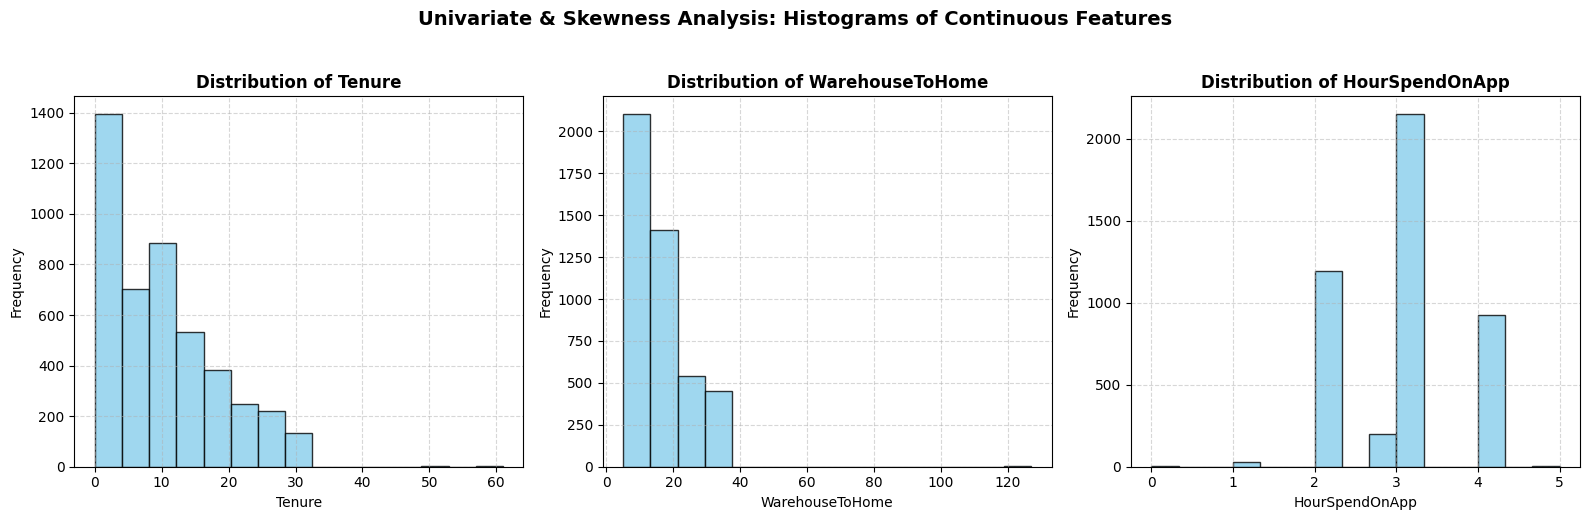

In [123]:
# Task I - Histogram for Tenure, WarehouseToHome and HourSpendOnApp

import matplotlib.pyplot as plt

histogram_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(histogram_features):
    ax = axes[i]
    data = df_cleaned[col].dropna()

    ax.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.8)

    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Univariate & Skewness Analysis: Histograms of Continuous Features', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

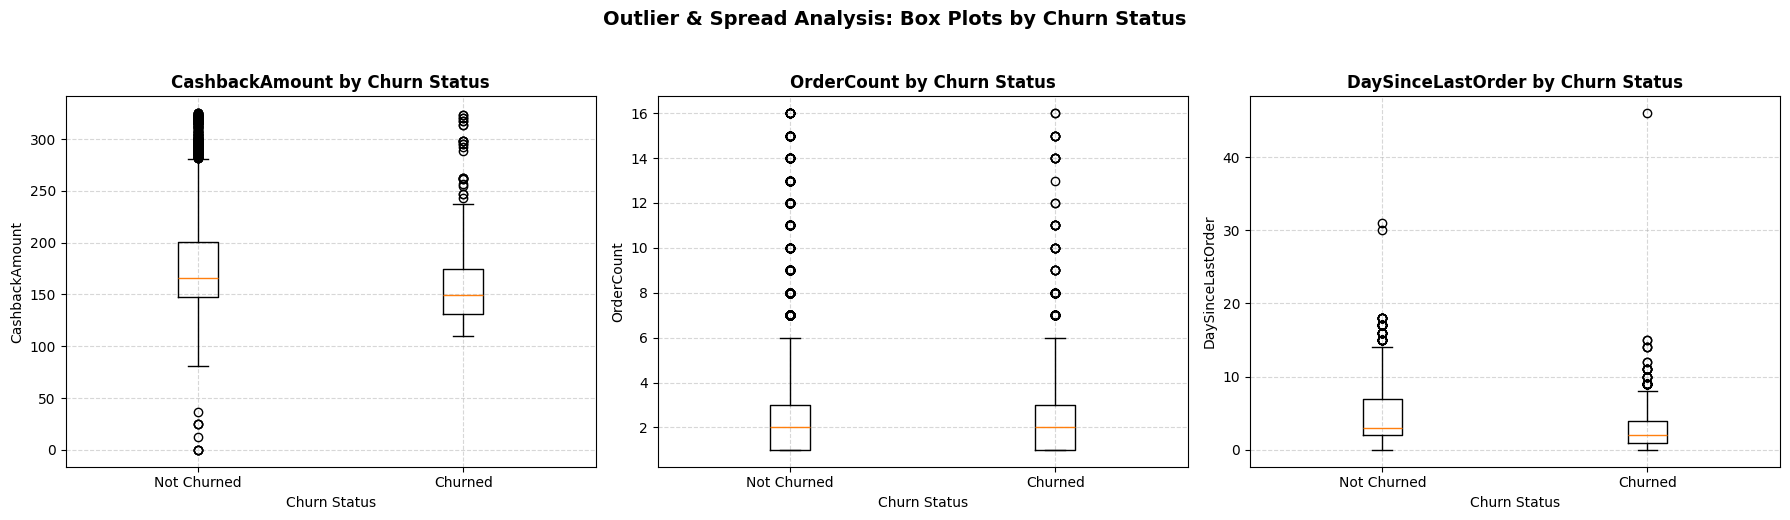

In [124]:
# Task I - Box Plot
boxplot_features = ['CashbackAmount', 'OrderCount', 'DaySinceLastOrder']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(boxplot_features):
    ax = axes[i]
    not_churned = df_cleaned[df_cleaned["Churn"] == 0][col].dropna()
    churned = df_cleaned[df_cleaned["Churn"] == 1][col].dropna()

    ax.boxplot([not_churned, churned], tick_labels=["Not Churned", "Churned"])
    ax.set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Status', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Outlier & Spread Analysis: Box Plots by Churn Status', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

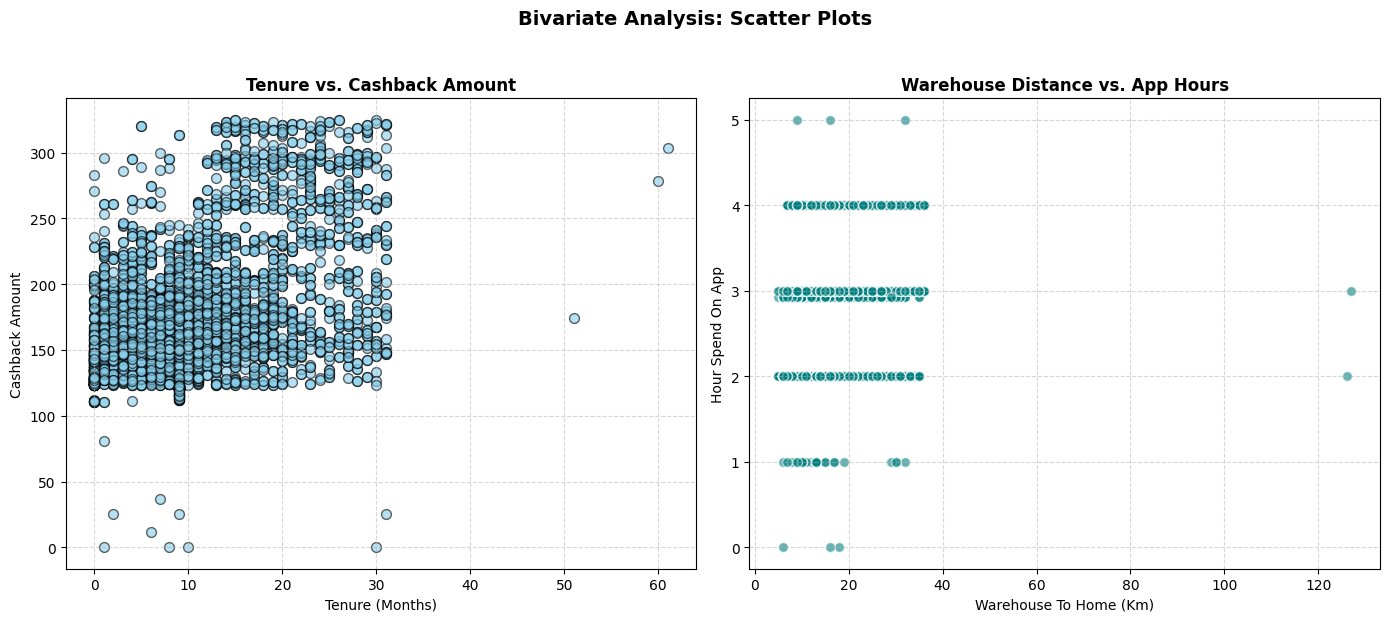

In [125]:
# Task I - Scatter Plot of Tenure vs CashBackAmount and WarehouseToHome vs HourSpendOnApp

import matplotlib.pyplot as plt

# Setting up a 1-row, 2-column canvas using subplot function
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(df_cleaned['Tenure'], df_cleaned['CashbackAmount'],
            color='skyblue', alpha=0.6, edgecolors='black', s=50)
ax1.set_title('Tenure vs. Cashback Amount', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tenure (Months)', fontsize=10)
ax1.set_ylabel('Cashback Amount', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.scatter(df_cleaned['WarehouseToHome'], df_cleaned['HourSpendOnApp'],
            color='teal', alpha=0.6, edgecolors='w', s=50)
ax2.set_title('Warehouse Distance vs. App Hours', fontsize=12, fontweight='bold')
ax2.set_xlabel('Warehouse To Home (Km)', fontsize=10)
ax2.set_ylabel('Hour Spend On App', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Bivariate Analysis: Scatter Plots', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

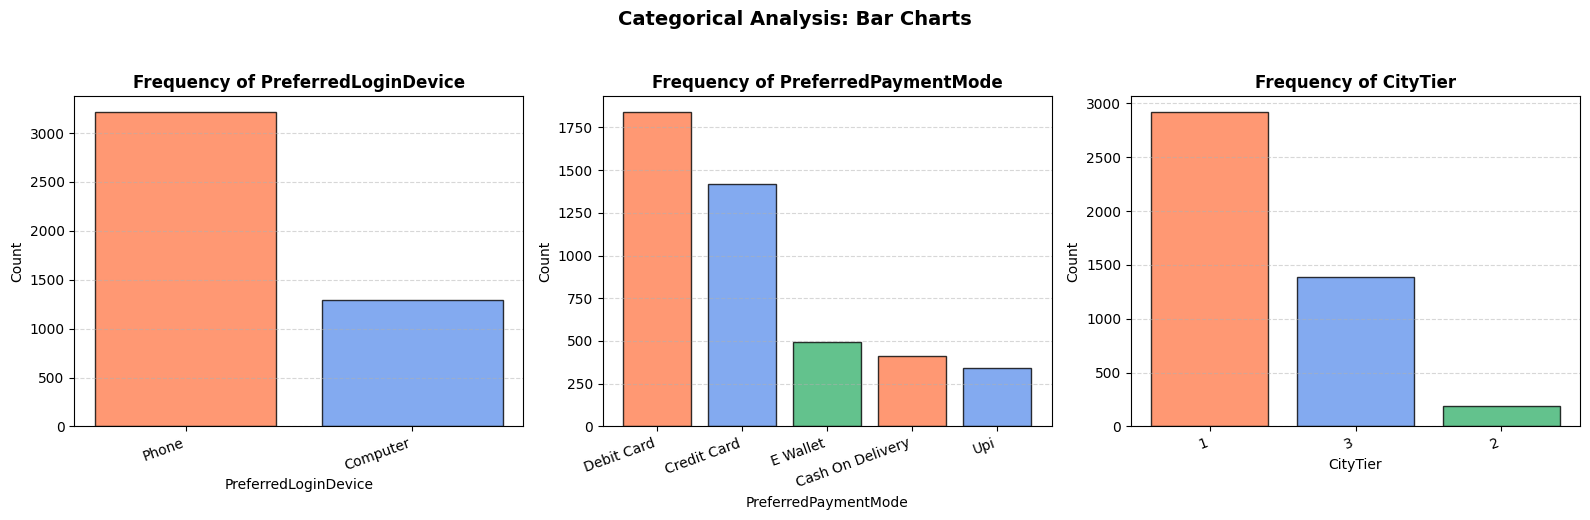

In [126]:
# Task I - Bar chart for PreferredLoginDevice, PreferredPaymentMode and CityTier

import matplotlib.pyplot as plt

bar_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'CityTier']

# Setting up a 1-row, 3-column canvas using subplot function
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(bar_features):
    ax = axes[i]

    counts = df_cleaned[col].value_counts()
    categories = [str(cat) for cat in counts.index]
    values = counts.values

    ax.bar(categories, values, color=['coral', 'cornflowerblue', 'mediumseagreen'], edgecolor='black', alpha=0.8)

    ax.set_title(f'Frequency of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

    # Rotating x-tick labels because the text is long (especially for payment modes)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Categorical Analysis: Bar Charts', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

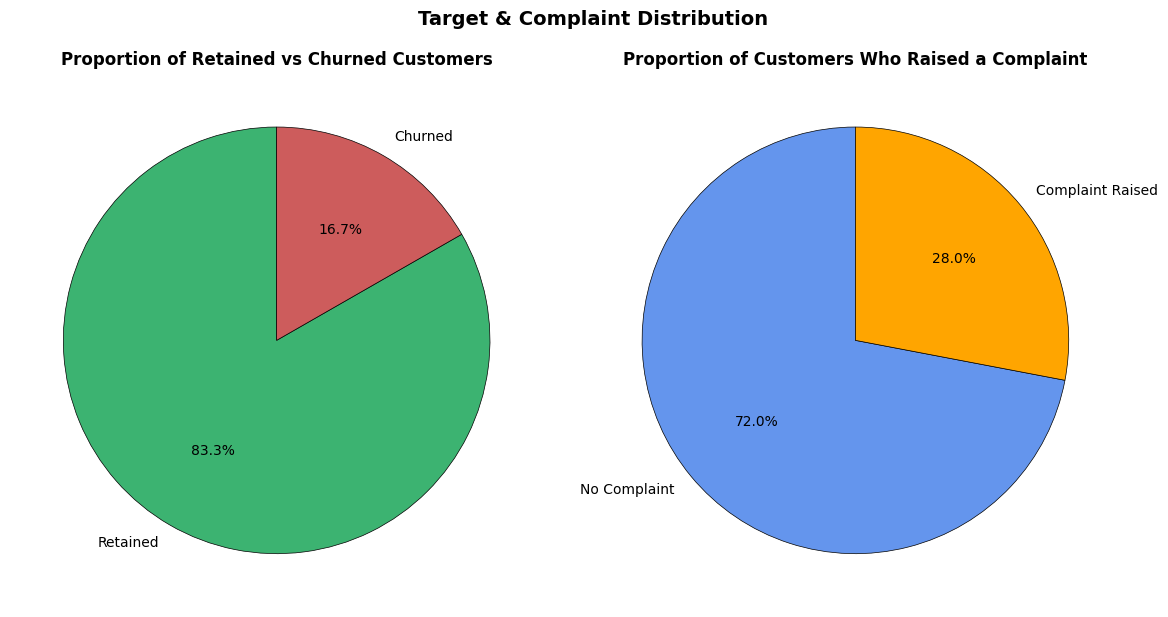

In [127]:
# Task I  - Pie Charts for Churn and Complain proportions
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Pie 1: Churn proportion ---
churn_counts = df_cleaned["Churn"].value_counts()
churn_labels = ["Retained", "Churned"]

axes[0].pie(churn_counts, labels=churn_labels, autopct='%1.1f%%',
            colors=['mediumseagreen', 'indianred'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[0].set_title('Proportion of Retained vs Churned Customers', fontsize=12, fontweight='bold')

# Pie 2: Complain proportion
complain_counts = df_cleaned["Complain"].value_counts()
complain_labels = ["No Complaint", "Complaint Raised"]

axes[1].pie(complain_counts, labels=complain_labels, autopct='%1.1f%%',
            colors=['cornflowerblue', 'orange'], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Proportion of Customers Who Raised a Complaint', fontsize=12, fontweight='bold')

plt.suptitle('Target & Complaint Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

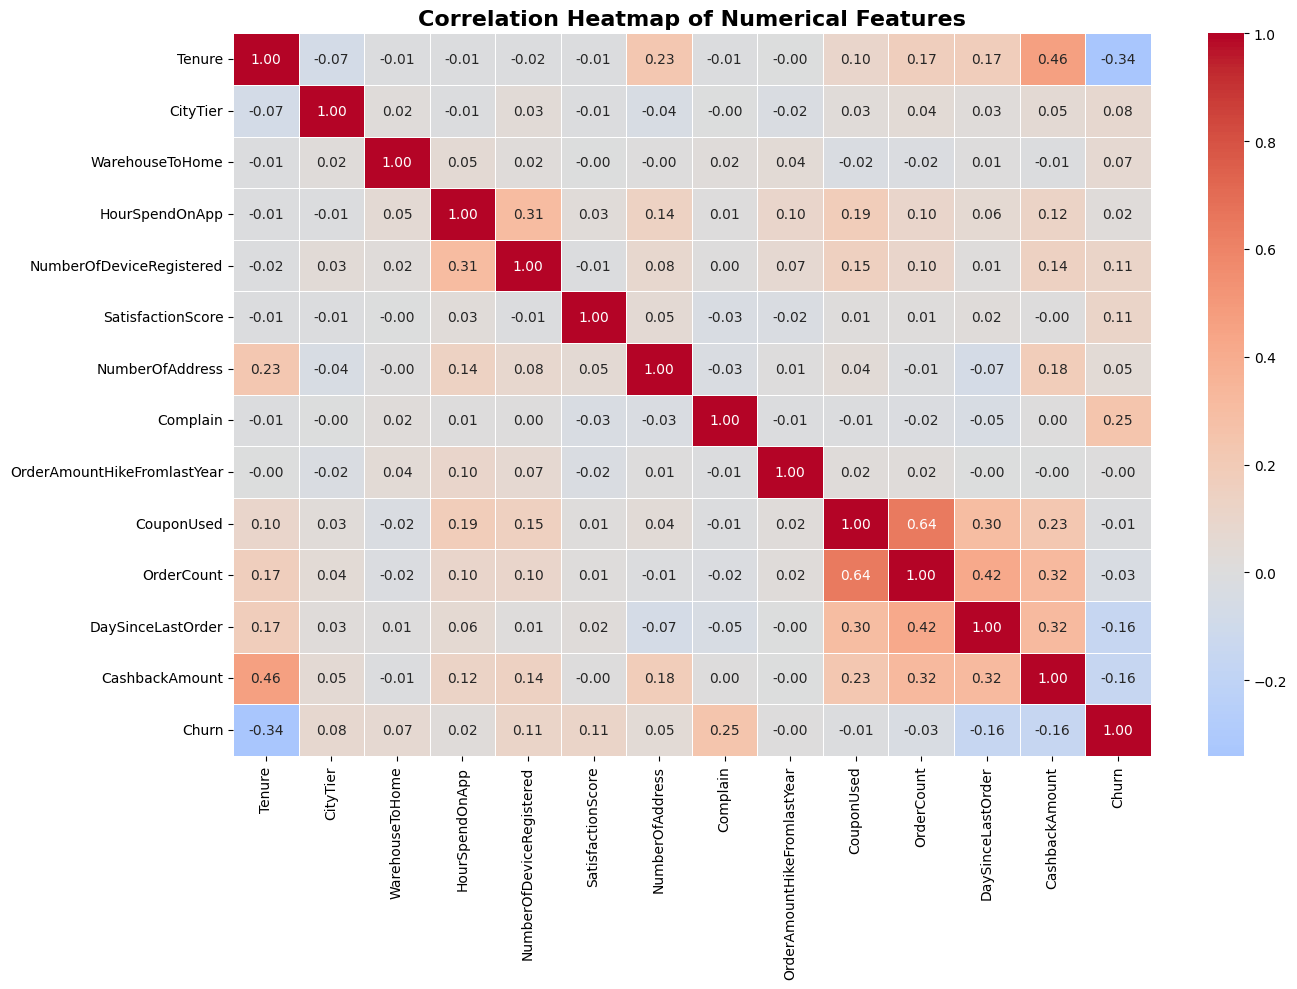

In [128]:
# Task I - Correlation Heatmap of Numerical Features
import seaborn as sns

numerical_columns = [
    "Tenure",
    "CityTier",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
    "Churn"
]

correlation_matrix = pd.DataFrame(0.0,index=numerical_columns,columns=numerical_columns)

for col1 in numerical_columns:
    for col2 in numerical_columns:

        x = df_cleaned[col1].values
        y = df_cleaned[col2].values

        mean_x = np.mean(x)
        mean_y = np.mean(y)

        numerator = 0
        denominator_x = 0
        denominator_y = 0

        for i in range(len(x)):
            numerator += (x[i] - mean_x) * (y[i] - mean_y)
            denominator_x += (x[i] - mean_x) ** 2
            denominator_y += (y[i] - mean_y) ** 2

        correlation = numerator / np.sqrt(
            denominator_x * denominator_y
        )

        correlation_matrix.loc[col1, col2] = correlation

correlation_matrix

# Plot heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,center=0)

plt.title("Correlation Heatmap of Numerical Features",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

In [129]:
#  Train-Test Split (80/20)
# import random

# def train_test_split_manual(df, test_ratio=0.20, seed=42):

#     total_rows = len(df)

#     #  Get all row indices as a list
#     indices = list(df.index)

#     #  Shuffle them randomly
#     random.seed(seed)
#     random.shuffle(indices)

#     #  Calculate split point
#     test_size = int(total_rows * test_ratio)

#     # Slice the shuffled indices
#     test_indices = indices[:test_size]
#     train_indices = indices[test_size:]

#     #  Using these indices to create actual train/test dataframes
#     train_df = df.loc[train_indices]
#     test_df = df.loc[test_indices]

#     return train_df, test_df

# train_df, test_df = train_test_split_manual(df_cleaned, test_ratio=0.20, seed=42)

# # Save train and test datasets as CSV files
# train_df.to_csv("train_dataset.csv", index=False)
# test_df.to_csv("test_dataset.csv", index=False)

# print("Original dataset size:", len(df_cleaned))
# print("Training set size:", len(train_df), f"({len(train_df)/len(df_cleaned)*100:.1f}%)")
# print("Testing set size:", len(test_df), f"({len(test_df)/len(df_cleaned)*100:.1f}%)")

In [130]:
#  Library verification
# from sklearn.model_selection import train_test_split

# train_lib, test_lib = train_test_split(df_cleaned, test_size=0.20, random_state=42)

# print("Manual split sizes match sklearn split sizes:",
#       len(train_df) == len(train_lib) and len(test_df) == len(test_lib))

In [131]:
#M1
import pandas as pd

train_df = pd.read_csv("https://raw.githubusercontent.com/DrishtiNigam1928/CUSTOMER_CHURN/main/dataset/train_dataset.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/DrishtiNigam1928/CUSTOMER_CHURN/main/dataset/test_dataset.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (4504, 36)
Test shape: (1126, 36)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,PreferredPaymentMode_E_Wallet,PreferredPaymentMode_Upi,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop_&_Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,51783,0,3.0,Phone,3,13.0,E Wallet,Male,2.931535,3,...,1,0,0,0,0,1,0,0,0,1
1,53527,1,1.0,Phone,3,30.0,Debit Card,Female,3.000000,5,...,0,0,1,0,0,0,0,1,0,0
2,51188,1,0.0,Phone,2,24.0,Upi,Male,2.931535,1,...,0,1,0,0,0,1,0,0,1,0
3,50275,0,9.0,Phone,1,6.0,Debit Card,Male,3.000000,4,...,0,0,0,0,0,1,0,1,0,0
4,53337,0,27.0,Phone,3,15.0,E Wallet,Male,4.000000,4,...,1,0,0,1,0,0,0,1,0,0


In [132]:
def calc_mean(values):
    return sum(values) / len(values)

def calc_variance(values, mean_val):
    squared_diffs = [(v - mean_val) ** 2 for v in values]
    return sum(squared_diffs) / len(values)

exclude_cols = ["CustomerID", "Churn"]
numeric_input_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_input_cols = [c for c in numeric_input_cols if c not in exclude_cols]

variance_report = []
for col in numeric_input_cols:
    values = train_df[col].dropna().tolist()
    mean_val = calc_mean(values)
    var_val = calc_variance(values, mean_val)
    variance_report.append({"Feature": col, "Variance": var_val})

variance_table = pd.DataFrame(variance_report).sort_values("Variance").reset_index(drop=True)
variance_table

,Feature,Variance
0,PreferedOrderCat_Others,0.044854
1,PreferedOrderCat_Grocery,0.066951
2,PreferredPaymentMode_Upi,0.069601
3,PreferredPaymentMode_Cash_On_Delivery,0.082925
4,PreferredPaymentMode_E_Wallet,0.097651
5,PreferedOrderCat_Fashion,0.124906
6,MaritalStatus_Divorced,0.125063
7,Complain,0.201588
8,PreferredLoginDevice_Phone,0.204285
9,PreferredLoginDevice_Computer,0.204285


In [133]:
def classify_variance(v):
    if v == 0:
        return "Zero-variance"
    elif v < 0.01:
        return "Near-zero-variance"
    elif v < 1:
        return "Low-variance"
    else:
        return "Acceptable"

variance_table["Category"] = variance_table["Variance"].apply(classify_variance)
variance_table["Decision"] = variance_table["Category"].apply(
    lambda c: "Remove" if c in ["Zero-variance", "Near-zero-variance"] else "Keep"
)
variance_table["Reason"] = variance_table.apply(
    lambda row: f"{row['Category']} ({row['Variance']:.4f}) -> little/no discriminatory information"
    if row["Decision"] == "Remove"
    else f"{row['Category']} ({row['Variance']:.4f}) -> sufficient spread, potentially useful",
    axis=1
)

print("Task M1: Variance Threshold completed successfully from scratch!\n")
variance_table

Task M1: Variance Threshold completed successfully from scratch!



,Feature,Variance,Category,Decision,Reason
0,PreferedOrderCat_Others,0.044854,Low-variance,Keep,"Low-variance (0.0449) -> sufficient spread, po..."
1,PreferedOrderCat_Grocery,0.066951,Low-variance,Keep,"Low-variance (0.0670) -> sufficient spread, po..."
2,PreferredPaymentMode_Upi,0.069601,Low-variance,Keep,"Low-variance (0.0696) -> sufficient spread, po..."
3,PreferredPaymentMode_Cash_On_Delivery,0.082925,Low-variance,Keep,"Low-variance (0.0829) -> sufficient spread, po..."
4,PreferredPaymentMode_E_Wallet,0.097651,Low-variance,Keep,"Low-variance (0.0977) -> sufficient spread, po..."
5,PreferedOrderCat_Fashion,0.124906,Low-variance,Keep,"Low-variance (0.1249) -> sufficient spread, po..."
6,MaritalStatus_Divorced,0.125063,Low-variance,Keep,"Low-variance (0.1251) -> sufficient spread, po..."
7,Complain,0.201588,Low-variance,Keep,"Low-variance (0.2016) -> sufficient spread, po..."
8,PreferredLoginDevice_Phone,0.204285,Low-variance,Keep,"Low-variance (0.2043) -> sufficient spread, po..."
9,PreferredLoginDevice_Computer,0.204285,Low-variance,Keep,"Low-variance (0.2043) -> sufficient spread, po..."


In [134]:
from sklearn.feature_selection import VarianceThreshold

check_data = train_df[numeric_input_cols].dropna()
selector = VarianceThreshold(threshold=0.0)
selector.fit(check_data)
lib_variances = selector.variances_

lib_check = pd.DataFrame({"Feature": numeric_input_cols, "Lib Variance": lib_variances})
merged_check = variance_table.merge(lib_check, on="Feature")
merged_check["Match"] = np.isclose(merged_check["Variance"], merged_check["Lib Variance"], atol=1e-6)

merged_check[["Feature", "Variance", "Lib Variance", "Match"]]

,Feature,Variance,Lib Variance,Match
0,PreferedOrderCat_Others,0.044854,0.044854,True
1,PreferedOrderCat_Grocery,0.066951,0.066951,True
2,PreferredPaymentMode_Upi,0.069601,0.069601,True
3,PreferredPaymentMode_Cash_On_Delivery,0.082925,0.082925,True
4,PreferredPaymentMode_E_Wallet,0.097651,0.097651,True
5,PreferedOrderCat_Fashion,0.124906,0.124906,True
6,MaritalStatus_Divorced,0.125063,0.125063,True
7,Complain,0.201588,0.201588,True
8,PreferredLoginDevice_Phone,0.204285,0.204285,True
9,PreferredLoginDevice_Computer,0.204285,0.204285,True


In [135]:
# M2: Pearson Correlation Function

pearson_features = [
    "Tenure",
    "CityTier",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

print("Number of numerical features:", len(pearson_features))
print(pearson_features)

def calc_pearson(x, y):

    # Remove rows where either value is missing
    paired_values = []

    for i in range(len(x)):
        if pd.notna(x[i]) and pd.notna(y[i]):
            paired_values.append((x[i], y[i]))

    x_clean = [pair[0] for pair in paired_values]
    y_clean = [pair[1] for pair in paired_values]

    # Calculate means
    mean_x = calc_mean(x_clean)
    mean_y = calc_mean(y_clean)

    # Calculate numerator and denominator
    numerator = 0
    sum_x_squared = 0
    sum_y_squared = 0

    for i in range(len(x_clean)):

        x_diff = x_clean[i] - mean_x
        y_diff = y_clean[i] - mean_y

        numerator += x_diff * y_diff
        sum_x_squared += x_diff ** 2
        sum_y_squared += y_diff ** 2

    denominator = (sum_x_squared * sum_y_squared) ** 0.5

    # Avoid division by zero
    if denominator == 0:
        return 0

    return numerator / denominator

Number of numerical features: 13
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [136]:
# M2: Feature-Target Correlation

feature_target_results = []

for feature in pearson_features:

    x = df_cleaned[feature].tolist()
    y = df_cleaned[target_col].tolist()

    correlation = calc_pearson(x, y)

    feature_target_results.append({
        "Feature": feature,
        "Target": target_col,
        "Pearson Correlation": correlation
    })

feature_target_table = pd.DataFrame(feature_target_results)

feature_target_table["Pearson Correlation"] = \
    feature_target_table["Pearson Correlation"].round(4)

display(feature_target_table)

,Feature,Target,Pearson Correlation
0,Tenure,Churn,-0.3406
1,CityTier,Churn,0.0769
2,WarehouseToHome,Churn,0.0674
3,HourSpendOnApp,Churn,0.0192
4,NumberOfDeviceRegistered,Churn,0.1114
5,SatisfactionScore,Churn,0.1134
6,NumberOfAddress,Churn,0.0460
7,Complain,Churn,0.2467
8,OrderAmountHikeFromlastYear,Churn,-0.0002
9,CouponUsed,Churn,-0.0084


In [137]:
# M2: Feature-Feature Correlation Matrix

correlation_matrix = pd.DataFrame(
    0.0,
    index=pearson_features,
    columns=pearson_features
)

for i in range(len(pearson_features)):

    for j in range(len(pearson_features)):

        feature_1 = pearson_features[i]
        feature_2 = pearson_features[j]

        x = df_cleaned[feature_1].tolist()
        y = df_cleaned[feature_2].tolist()

        correlation = calc_pearson(x, y)

        correlation_matrix.loc[
            feature_1,
            feature_2
        ] = correlation

display(correlation_matrix.round(4))

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Tenure,1.0000,-0.0712,-0.0136,-0.0146,-0.0151,-0.0117,0.2323,-0.0135,-0.0026,0.0978,0.1669,0.1748,0.4638
CityTier,-0.0712,1.0000,0.0190,-0.0085,0.0316,-0.0109,-0.0397,-0.0010,-0.0229,0.0288,0.0424,0.0253,0.0502
WarehouseToHome,-0.0136,0.0190,1.0000,0.0540,0.0201,-0.0033,-0.0002,0.0168,0.0434,-0.0213,-0.0179,0.0077,-0.0112
HourSpendOnApp,-0.0146,-0.0085,0.0540,1.0000,0.3051,0.0293,0.1383,0.0075,0.0998,0.1870,0.1019,0.0580,0.1230
NumberOfDeviceRegistered,-0.0151,0.0316,0.0201,0.3051,1.0000,-0.0084,0.0846,0.0021,0.0722,0.1539,0.1003,0.0130,0.1444
SatisfactionScore,-0.0117,-0.0109,-0.0033,0.0293,-0.0084,1.0000,0.0533,-0.0329,-0.0215,0.0116,0.0121,0.0243,-0.0002
NumberOfAddress,0.2323,-0.0397,-0.0002,0.1383,0.0846,0.0533,1.0000,-0.0277,0.0087,0.0350,-0.0135,-0.0659,0.1780
Complain,-0.0135,-0.0010,0.0168,0.0075,0.0021,-0.0329,-0.0277,1.0000,-0.0082,-0.0143,-0.0170,-0.0464,0.0006
OrderAmountHikeFromlastYear,-0.0026,-0.0229,0.0434,0.0998,0.0722,-0.0215,0.0087,-0.0082,1.0000,0.0242,0.0164,-0.0005,-0.0033
CouponUsed,0.0978,0.0288,-0.0213,0.1870,0.1539,0.0116,0.0350,-0.0143,0.0242,1.0000,0.6435,0.2983,0.2297


In [138]:
# M2: Identify Potentially Redundant Features

correlation_threshold = 0.80

redundant_features = []

for i in range(len(pearson_features)):

    for j in range(i + 1, len(pearson_features)):

        feature_1 = pearson_features[i]
        feature_2 = pearson_features[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(correlation) >= correlation_threshold:

            redundant_features.append({
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Pearson Correlation": round(correlation, 4)
            })

redundant_features_table = pd.DataFrame(
    redundant_features
)

if len(redundant_features_table) == 0:

    print(
        "No highly correlated feature pairs found "
        "at threshold", correlation_threshold
    )

else:

    display(redundant_features_table)

No highly correlated feature pairs found at threshold 0.8


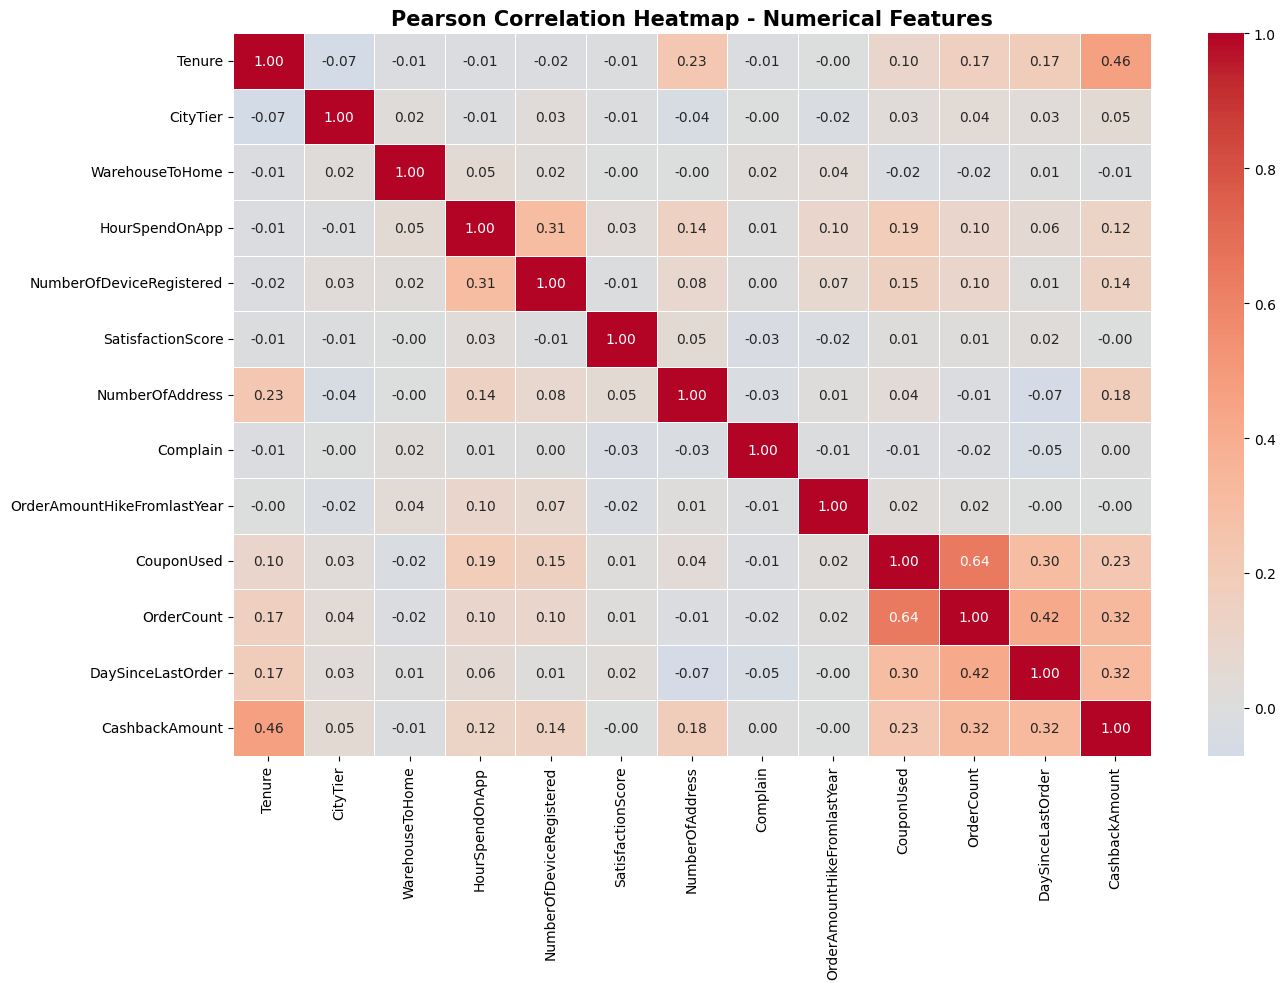

In [139]:
# M2: Pearson Correlation Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Pearson Correlation Heatmap - Numerical Features",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [140]:
# M2: Feature-Target Correlation Interpretation

def interpret_correlation(r):

    if abs(r) >= 0.80:
        strength = "Strong"
    elif abs(r) >= 0.50:
        strength = "Moderate"
    elif abs(r) >= 0.30:
        strength = "Weak"
    else:
        strength = "Very Weak / Near Zero"

    if r > 0:
        direction = "Positive"
    elif r < 0:
        direction = "Negative"
    else:
        direction = "Zero"

    return direction + " " + strength


interpretation_results = []

for row in feature_target_results:

    feature = row["Feature"]
    correlation = row["Pearson Correlation"]

    interpretation_results.append({
        "Feature": feature,
        "Correlation with Churn": round(correlation, 4),
        "Interpretation": interpret_correlation(correlation)
    })

interpretation_table = pd.DataFrame(
    interpretation_results
)

display(interpretation_table)

,Feature,Correlation with Churn,Interpretation
0,Tenure,-0.3406,Negative Weak
1,CityTier,0.0769,Positive Very Weak / Near Zero
2,WarehouseToHome,0.0674,Positive Very Weak / Near Zero
3,HourSpendOnApp,0.0192,Positive Very Weak / Near Zero
4,NumberOfDeviceRegistered,0.1114,Positive Very Weak / Near Zero
5,SatisfactionScore,0.1134,Positive Very Weak / Near Zero
6,NumberOfAddress,0.0460,Positive Very Weak / Near Zero
7,Complain,0.2467,Positive Very Weak / Near Zero
8,OrderAmountHikeFromlastYear,-0.0002,Negative Very Weak / Near Zero
9,CouponUsed,-0.0084,Negative Very Weak / Near Zero


In [141]:
# M2: Library Verification of Correlation Matrix

lib_correlation_matrix = df_cleaned[pearson_features].corr()

# Compare manual correlation matrix with library result
correlation_match = np.isclose(
    correlation_matrix.values,
    lib_correlation_matrix.values,
    atol=1e-6
)

print("All correlations match:",
      correlation_match.all())

All correlations match: True


In [142]:
# M4: ANOVA F-TEST

import pandas as pd
import numpy as np
from scipy.stats import f as f_dist

features_to_test = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'NumberOfDeviceRegistered',
    'NumberOfAddress',
    'OrderCount',
    'CouponUsed',
    'DaySinceLastOrder',
    'CityTier',
    'SatisfactionScore',
    'OrderAmountHikeFromlastYear',
    'Complain',
    'CashbackAmount'
]

features_for_anova = [col for col in features_to_test if col in df_cleaned.columns]
anova_df = df_cleaned[features_for_anova + ['Churn']].dropna()

anova_results_scratch = []

n = len(anova_df)
groups = anova_df['Churn'].unique()
k = len(groups)

# Degrees of freedom
df_between = k - 1
df_within = n - k

alpha = 0.05
critical_f_value = f_dist.ppf(1 - alpha, df_between, df_within)

for col in features_for_anova:
    all_values = anova_df[col].tolist()

    # Mean using custom B2 functions
    overall_mean = calc_mean(all_values)

    # Calculating SSB and SSW
    ssb = 0.0
    ssw = 0.0
    for g in groups:
        group_data = anova_df[anova_df['Churn'] == g][col].tolist()
        n_g = len(group_data)

        if n_g > 0:
            # Group Mean using custom B2 function
            g_mean = calc_mean(group_data)
            ssb += n_g * ((g_mean - overall_mean) ** 2)

            # SSW using custom B2 function
            g_var = calc_variance(group_data, g_mean)
            ssw += g_var * (n_g - 1)

    # Mean Squares
    ms_between = ssb / df_between if df_between > 0 else 0
    ms_within = ssw / df_within if df_within > 0 else 0

    # F-Statistic
    f_score = ms_between / ms_within if ms_within > 0 else 0.0

    is_significant = f_score > critical_f_value

    anova_results_scratch.append({
        'Feature': col,
        'F-Score (Scratch)': round(f_score, 4),
        'Critical F': round(critical_f_value, 4),
        'Significant (Alpha = 0.05)': is_significant,
        'SSB': round(ssb, 4),
        'SSW': round(ssw, 4)
    })

anova_scratch_table = pd.DataFrame(anova_results_scratch).sort_values(by='F-Score (Scratch)', ascending=False)

print("Task M4: ANOVA F-Test computed successfully from scratch using B2 functions!")
display(anova_scratch_table)

Task M4: ANOVA F-Test computed successfully from scratch using B2 functions!


,Feature,F-Score (Scratch),Critical F,Significant (Alpha = 0.05),SSB,SSW
0,Tenure,591.1992,3.8435,True,36639.5913,2.790116e+05
11,Complain,291.9845,3.8435,True,55.2742,8.522528e+02
7,DaySinceLastOrder,114.0729,3.8435,True,1435.7984,5.666520e+04
12,CashbackAmount,112.8915,3.8435,True,267038.7051,1.064924e+07
9,SatisfactionScore,58.6626,3.8435,True,111.2787,8.539967e+03
3,NumberOfDeviceRegistered,56.5507,3.8435,True,57.6163,4.586829e+03
8,CityTier,26.8123,3.8435,True,22.4394,3.767766e+03
1,WarehouseToHome,20.5784,3.8435,True,1438.9372,3.148001e+05
4,NumberOfAddress,9.5425,3.8435,True,63.1708,2.980310e+04
5,OrderCount,4.5357,3.8435,True,38.0218,3.773910e+04
